In [66]:
import icdv as icdv
import numpy as np
import pandas as pd

In [67]:
# 1) Convertir Excel a CSV (una sola vez)
#icdv.processing.arbin_excel_a_csv("../data/raw/jd_grcom_sw3_c_1_sinresorte_doslanavidrio.xls", "./tmp/ARBIN_jd_grcom_sw3_c_1_sinresorte_doslanavidrio")

In [68]:
# 2) Cargar todos los CSV (rápido)
df_all = icdv.processing.cargar_csv_arbin("/home/mariajose/proc-icdv/notebooks/tmp/ARBIN_jd_grcom_sw3_c_1_sinresorte_doslanavidrio")

df_all.head()


,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,60.003153,2026-04-22 14:47:38,60.003154,1,1,0.0,1.757690,0.0,1.477530e-09,0.0,2.594772e-09,-0.003071,0,0,0,0
1,2,120.004325,2026-04-22 14:48:38,120.004325,1,1,0.0,1.759532,0.0,1.477530e-09,0.0,2.594772e-09,0.000000,0,0,0,0
2,3,180.011401,2026-04-22 14:49:38,180.011401,1,1,0.0,1.760760,0.0,1.477530e-09,0.0,2.594772e-09,0.000000,0,0,0,0
3,4,240.017683,2026-04-22 14:50:38,240.017683,1,1,0.0,1.762909,0.0,1.477530e-09,0.0,2.594772e-09,0.002976,0,0,0,0
4,5,300.026390,2026-04-22 14:51:38,300.026390,1,1,0.0,1.764137,0.0,1.477530e-09,0.0,2.594772e-09,0.002991,0,0,0,0


In [69]:
# 3) Procesar
dict_ciclos, dict_ciclos_sep, indices = icdv.processing.procesar_arbin(df_all)

In [70]:
print(dict_ciclos_sep[10]['Ch'].head())

      Time_s   Time_cont_s  Current_mA   CellV_V     Q_mAh     Energy_Wh  \
0  10.009404  38357.808779    0.316037  0.059183  0.000879  4.765153e-08   
1  20.016834  38367.816208    0.316037  0.063174  0.001757  1.015149e-07   
2  30.020199  38377.819573    0.316108  0.066551  0.002636  1.585029e-07   
3  40.022486  38387.821861    0.316037  0.069007  0.003514  2.178971e-07   
4  50.030943  38397.830318    0.316072  0.071155  0.004392  2.794102e-07   

    dVdt_Vs  dQdV_mAhV  
0  0.002794   0.031418  
1 -0.003069  -0.028602  
2  0.002789   0.031485  
3  0.000000        NaN  
4  0.000000        NaN  


In [71]:
print(len(indices))
print(indices[0:15])
print(indices[len(indices)-15:len(indices)])
print(dict_ciclos_sep[10]['Ch'].head())

92
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]
      Time_s   Time_cont_s  Current_mA   CellV_V     Q_mAh     Energy_Wh  \
0  10.009404  38357.808779    0.316037  0.059183  0.000879  4.765153e-08   
1  20.016834  38367.816208    0.316037  0.063174  0.001757  1.015149e-07   
2  30.020199  38377.819573    0.316108  0.066551  0.002636  1.585029e-07   
3  40.022486  38387.821861    0.316037  0.069007  0.003514  2.178971e-07   
4  50.030943  38397.830318    0.316072  0.071155  0.004392  2.794102e-07   

    dVdt_Vs  dQdV_mAhV  
0  0.002794   0.031418  
1 -0.003069  -0.028602  
2  0.002789   0.031485  
3  0.000000        NaN  
4  0.000000        NaN  


In [72]:
# Quitar ciclos anómalos

indices_originales = indices.copy()
indices = [i for i in indices if i not in [6,38,39,40,41,45,46,47,48,49,92]]

print(indices_originales)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]


La capacidad máxima es 3.679 mAh y se alcanza en el ciclo 1.


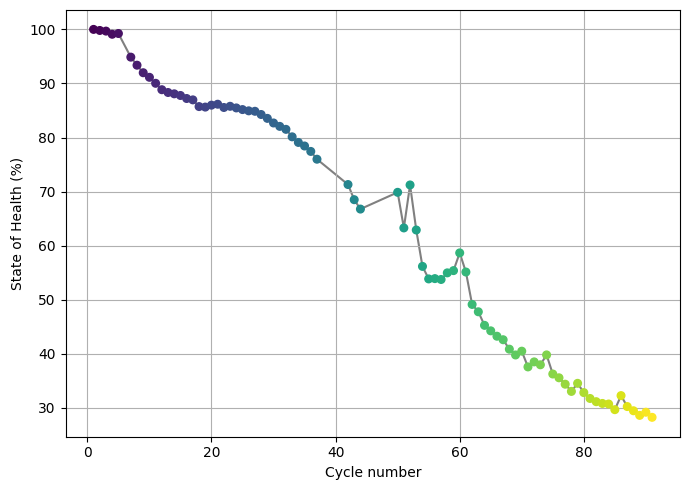

(    ciclo      qmax         soh
 0       1  3.678754  100.000000
 1       2  3.671508   99.803030
 2       3  3.667179   99.685354
 3       4  3.645666   99.100559
 4       5  3.650850   99.241474
 ..    ...       ...         ...
 76     87  1.113045   30.256022
 77     88  1.084492   29.479870
 78     89  1.053145   28.627770
 79     90  1.074481   29.207744
 80     91  1.039791   28.264756
 
 [81 rows x 3 columns],
 np.float64(3.678754470172),
 1)

In [73]:
icdv.plotting.plot_soh(indices[:], dict_ciclos_sep, var='Q_mAh', nombre_grafico='grcom')

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


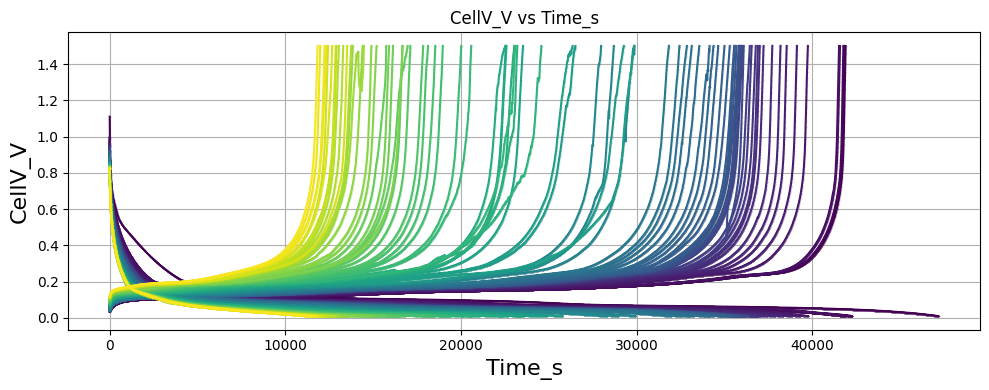

In [74]:
icdv.plotting.plot_n_cycles_tvsV(indices[:], dict_ciclos_sep, vars=['Time_s', 'CellV_V'], nombre_grafico='plot', scatter=False)

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


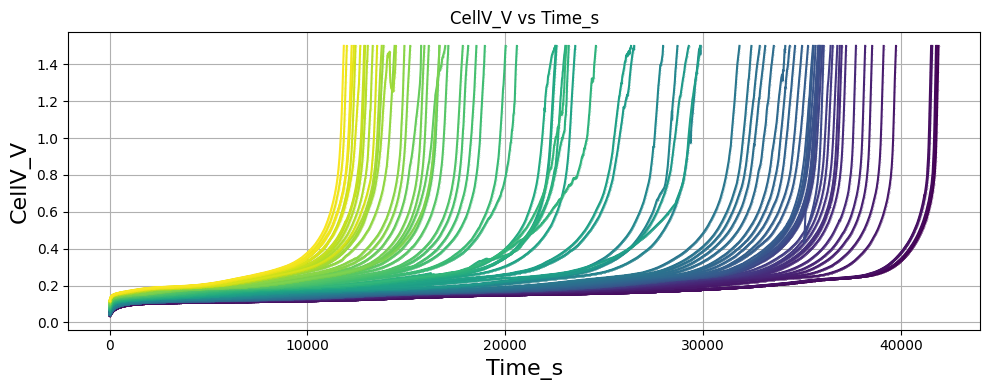

In [75]:
icdv.plotting.plot_n_cycles_tvsV(indices[:], dict_ciclos_sep, vars=['Time_s', 'CellV_V'], semi='Ch', nombre_grafico='plot', scatter=False)

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


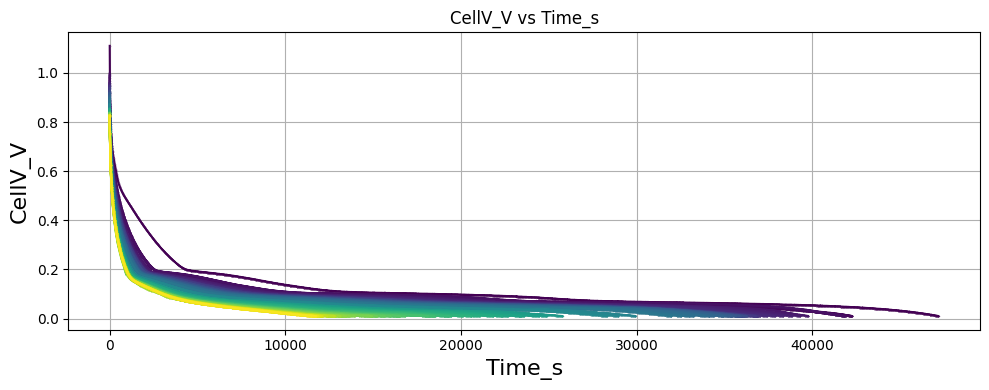

In [76]:
icdv.plotting.plot_n_cycles_tvsV(indices[:], dict_ciclos_sep, vars=['Time_s', 'CellV_V'], semi='Dis', nombre_grafico='plot', scatter=False)

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


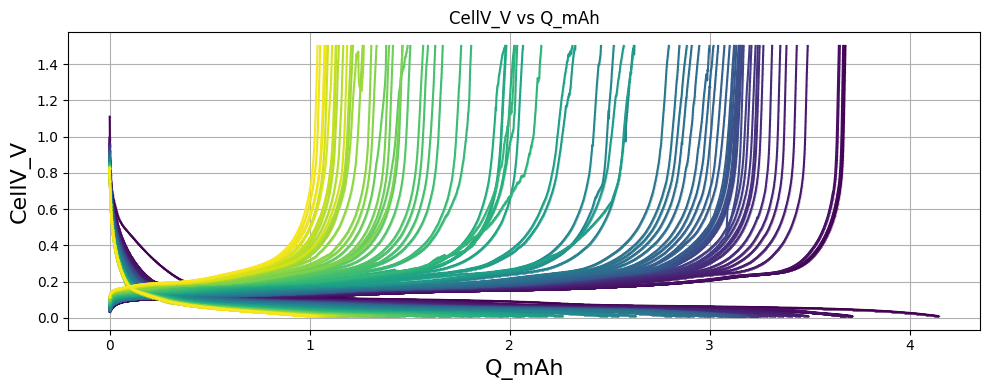

In [77]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep, vars=['Q_mAh', 'CellV_V'], nombre_grafico='plot', scatter=False)

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


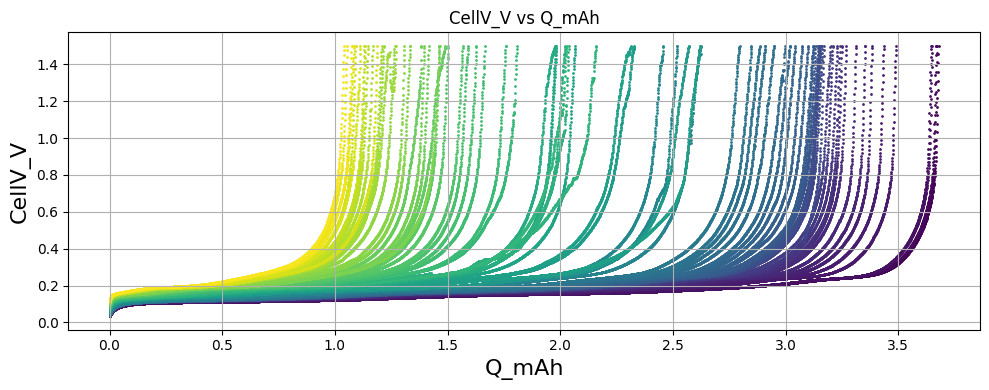

In [78]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep, vars=['Q_mAh', 'CellV_V'], semi='Ch', nombre_grafico='plot', scatter=False)

[2]


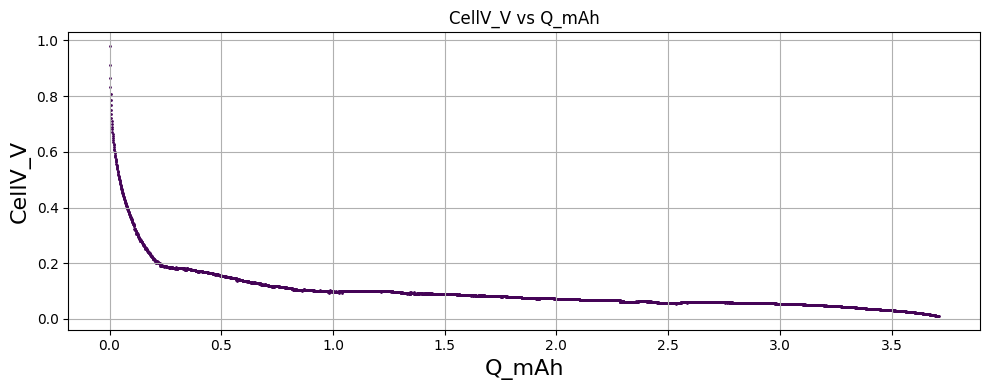

In [79]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[1:2], dict_ciclos_sep, vars=['Q_mAh', 'CellV_V'], semi='Dis', nombre_grafico='plot', scatter=False)

In [80]:
ciclo=10
columns = ['Time_s','Q_mAh','CellV_V','Current_mA']
print(dict_ciclos_sep[ciclo]['Ch'][columns].iloc[0:60])

        Time_s     Q_mAh   CellV_V  Current_mA
0    10.009404  0.000879  0.059183    0.316037
1    20.016834  0.001757  0.063174    0.316037
2    30.020199  0.002636  0.066551    0.316108
3    40.022486  0.003514  0.069007    0.316037
4    50.030943  0.004392  0.071155    0.316072
5    60.038220  0.005271  0.072997    0.316072
6    70.038751  0.006149  0.074839    0.316001
7    80.039914  0.007027  0.076374    0.316108
8    90.049268  0.007906  0.077909    0.316108
9   100.053701  0.008784  0.079137    0.316037
10  110.056991  0.009662  0.080365    0.316072
11  120.066451  0.010541  0.081900    0.316037
12  130.069691  0.011419  0.082821    0.316037
13  140.074185  0.012298  0.083741    0.316072
14  150.081437  0.013176  0.084662    0.316072
15  160.088754  0.014055  0.085583    0.316037
16  170.094147  0.014933  0.086504    0.316072
17  180.099461  0.015811  0.087425    0.316072
18  190.109889  0.016690  0.088039    0.316072
19  200.110262  0.017568  0.088653    0.316001
20  210.11760

In [81]:
import matplotlib.pyplot as plt

def grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[3]['Ch']['CellV_V'], y=dict_ciclos_sep[3]['Ch']['Q_mAh'], xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    plt.scatter(x,y, s=2)
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title(f'Cycle {ciclo} - {x.name} vs {y.name}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.show()

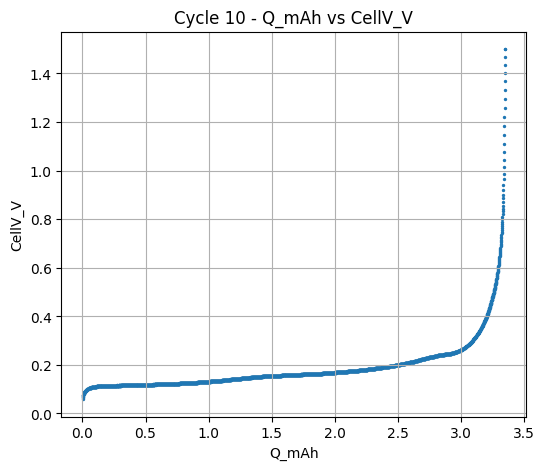

In [82]:
# Miro ciclos individualmente

ciclo = 10
grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['Q_mAh'], y=dict_ciclos_sep[ciclo]['Ch']['CellV_V'])#, xlim=(-0.001,0.05), ylim=(-0.2,0.2))  

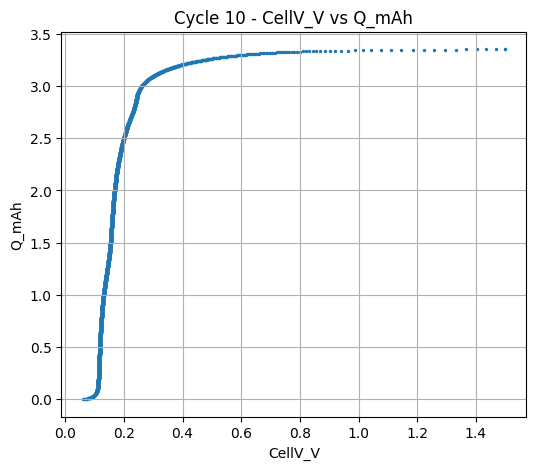

In [83]:
# Miro ciclos individualmente

ciclo = 10
grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['CellV_V'], y=dict_ciclos_sep[ciclo]['Ch']['Q_mAh'])#, xlim=(-0.001,0.05), ylim=(-0.2,0.2))  

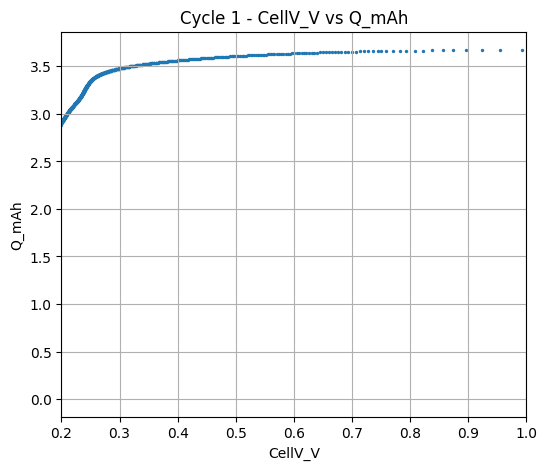

In [84]:
# Miro ciclos individualmente

ciclo = 1
grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['CellV_V'], y=dict_ciclos_sep[ciclo]['Ch']['Q_mAh'], xlim=(0.2,1.0))#, ylim=(-0.5,1))  

In [85]:
columns = ['Time_s','dVdt_Vs']
print(dict_ciclos_sep[ciclo]['Ch'][columns].iloc[0:20])

        Time_s   dVdt_Vs
0    10.007428  0.000000
1    20.009795  0.000000
2    30.012624  0.000000
3    40.013499  0.003039
4    50.016886  0.000000
5    60.025241  0.000000
6    70.027563  0.002791
7    80.035937  0.000000
8    90.039282  0.000000
9   100.048641 -0.005581
10  110.057994  0.000000
11  120.066356  0.000000
12  130.071732  0.000000
13  140.072075  0.000000
14  150.080455  0.003021
15  160.085837  0.000000
16  170.095126 -0.003039
17  180.097819  0.003061
18  190.105844  0.000000
19  200.108232  0.003010


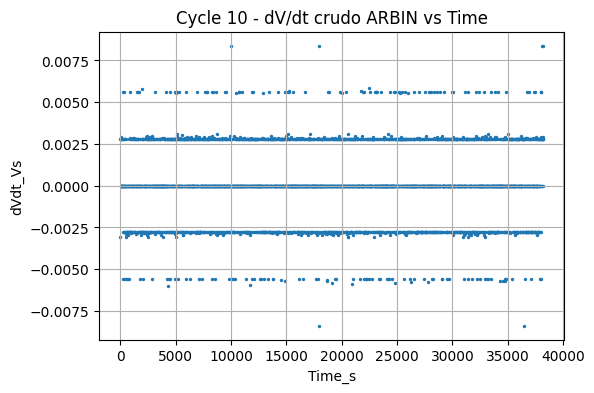

'\nEs la cuantización del ADC del Arbin. El voltaje está digitalizado en pasos discretos (LSB), entonces entre dos muestras consecutivas el voltaje:\n\nNo cambia → dV/dt = 0 (los que filtramos)\nSube 1 LSB → dV/dt = +LSB/Δt ≈ +0.0025 V/s\nBaja 1 LSB → dV/dt = -LSB/Δt ≈ -0.0025 V/s\nSube 2 LSB → dV/dt = +0.0050 V/s\n\nEntonces el LSB del equipo es aproximadamente 0.0025 × 10s ≈ 0.025 mV, lo cual es la resolución real del voltímetro.\nConclusión: la columna dV/dt(V/s) de Arbin no sirve para calcular dQ/dV. Es una diferencia finita punto a punto sobre una señal cuantizada, no una derivada real.\n'

In [94]:
ciclo = 10
df = dict_ciclos_sep[ciclo]['Ch']
mask = df['dVdt_Vs'] != 8000
plt.figure(figsize=(6,4))
plt.scatter(df.loc[mask, 'Time_s'], df.loc[mask, 'dVdt_Vs'], s=2)
plt.xlabel('Time_s')
plt.ylabel('dVdt_Vs')
plt.title(f'Cycle {ciclo} - dV/dt crudo ARBIN vs Time')
plt.grid()
plt.show()

'''
Es la cuantización del ADC del Arbin. El voltaje está digitalizado en pasos discretos (LSB), entonces entre dos muestras consecutivas el voltaje:

No cambia → dV/dt = 0 (los que filtramos)
Sube 1 LSB → dV/dt = +LSB/Δt ≈ +0.0025 V/s
Baja 1 LSB → dV/dt = -LSB/Δt ≈ -0.0025 V/s
Sube 2 LSB → dV/dt = +0.0050 V/s

Entonces el LSB del equipo es aproximadamente 0.0025 × 10s ≈ 0.025 mV, lo cual es la resolución real del voltímetro.
Conclusión: la columna dV/dt(V/s) de Arbin no sirve para calcular dQ/dV. Es una diferencia finita punto a punto sobre una señal cuantizada, no una derivada real.
'''

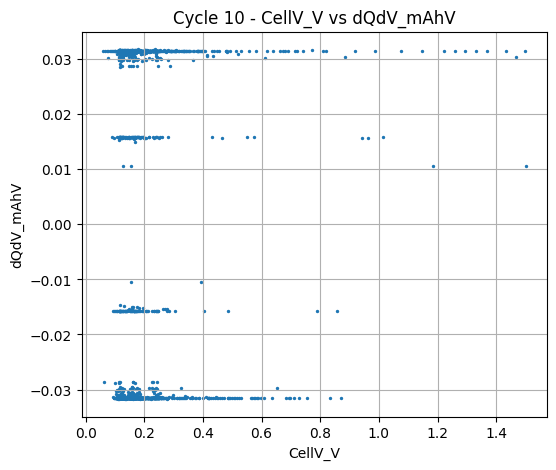

In [19]:
# Miro ciclos individualmente

ciclo = 10
grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['CellV_V'], y=dict_ciclos_sep[ciclo]['Ch']['dQdV_mAhV'])#, xlim=(0.08,0.12), ylim=(-0.5,1))  

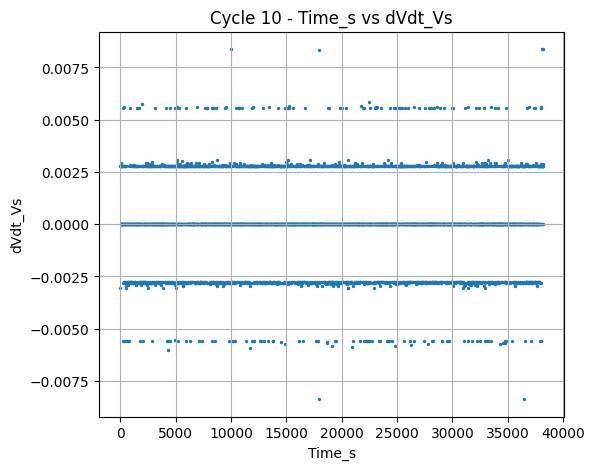

In [21]:
# Miro ciclos individualmente

ciclo = 10
grafico_QvsV_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['Time_s'], y=dict_ciclos_sep[ciclo]['Ch']['dVdt_Vs'])#, xlim=(0.08,0.12), ylim=(-0.5,1))  

In [34]:
# veo "resolucion efectiva" de t en el dataset
t = dict_ciclos_sep[10]['Ch']['Q_mAh'].values
dt = np.diff(np.unique(t))
np.min(dt), np.median(dt)

(np.float64(1.2554585000046359e-05), np.float64(0.0008784012750000514))

In [35]:
def verificar_monotonia(df_semi, col_Q='Q_mAh', col_V='CellV_V'):
    Q = df_semi[col_Q]
    dQ = Q.diff()
    
    n_negativos = (dQ < 0).sum()
    n_ceros     = (dQ == 0).sum()
    n_total     = len(Q)
    
    print(f"Total puntos  : {n_total}")
    print(f"dQ < 0        : {n_negativos} ({100*n_negativos/n_total:.2f}%)")
    print(f"dQ = 0        : {n_ceros}     ({100*n_ceros/n_total:.2f}%)")
    
    if n_negativos > 0:
        print("\nPuntos con dQ < 0:")
        mask = dQ < 0
        print(df_semi.loc[mask, [col_V, col_Q]].head(10))
    
    return n_negativos == 0

In [37]:
for ciclo in indices:
    print(f"\nCiclo {ciclo}:")
    verificar_monotonia(dict_ciclos_sep[ciclo]['Ch'], col_Q='Q_mAh', col_V='CellV_V')


Ciclo 1:
Total puntos  : 4188
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 2:
Total puntos  : 4180
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 3:
Total puntos  : 4176
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 4:
Total puntos  : 4151
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 5:
Total puntos  : 4156
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 7:
Total puntos  : 3973
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 8:
Total puntos  : 3911
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 9:
Total puntos  : 3853
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 10:
Total puntos  : 3818
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 11:
Total puntos  : 3771
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 12:
Total puntos  : 3721
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 13:
Total puntos  : 3700
dQ < 0  

In [38]:
for ciclo in indices:
    print(f"\nCiclo {ciclo}:")
    verificar_monotonia(dict_ciclos_sep[ciclo]['Ch'], col_Q='Time_s', col_V='CellV_V')


Ciclo 1:
Total puntos  : 4188
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 2:
Total puntos  : 4180
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 3:
Total puntos  : 4176
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 4:
Total puntos  : 4151
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 5:
Total puntos  : 4156
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 7:
Total puntos  : 3973
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 8:
Total puntos  : 3911
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 9:
Total puntos  : 3853
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 10:
Total puntos  : 3818
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 11:
Total puntos  : 3771
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 12:
Total puntos  : 3721
dQ < 0        : 0 (0.00%)
dQ = 0        : 0     (0.00%)

Ciclo 13:
Total puntos  : 3700
dQ < 0  

In [46]:
def verificar_monotonia_todos(dict_ciclos_sep, indices_ciclos, semi='Ch', col_Q='Q_mAh', col_V='CellV_V'):
    """
    Corre verificar_monotonia sobre todos los ciclos para un semi-ciclo dado.
    Devuelve un DataFrame resumen con el estado de cada ciclo.
    """
    resultados = []

    for ciclo in indices_ciclos:
        df_semi = dict_ciclos_sep[ciclo].get(semi)
        if df_semi is None or len(df_semi) == 0:
            resultados.append({'ciclo': ciclo, 'n_total': 0, 'n_negativos': 0, 'n_ceros': 0, 'pct_negativos': 0, 'estado': 'VACIO'})
            continue

        Q  = df_semi[col_Q]
        dQ = Q.diff()

        n_total     = len(Q)
        n_negativos = (dQ < 0).sum()
        n_ceros     = (dQ == 0).sum()
        pct_neg     = 100 * n_negativos / n_total

        if n_negativos == 0:
            estado = 'OK'
        elif pct_neg < 0.5:
            estado = 'CORREGIBLE'  # pocos puntos, np.maximum.accumulate alcanza
        else:
            estado = 'REVISAR'     # muchos puntos, algo raro en los datos

        resultados.append({
            'ciclo'        : ciclo,
            'n_total'      : n_total,
            'n_negativos'  : n_negativos,
            'n_ceros'      : n_ceros,
            'pct_negativos': round(pct_neg, 3),
            'estado'       : estado,
        })

    df_resumen = pd.DataFrame(resultados).set_index('ciclo')

    # Resumen en consola
    n_ok         = (df_resumen['estado'] == 'OK').sum()
    n_corregible = (df_resumen['estado'] == 'CORREGIBLE').sum()
    n_revisar    = (df_resumen['estado'] == 'REVISAR').sum()
    n_vacio      = (df_resumen['estado'] == 'VACIO').sum()

    print(f"Semi-ciclo: {semi}")
    print(f"  OK          : {n_ok}")
    print(f"  CORREGIBLE  : {n_corregible}")
    print(f"  REVISAR     : {n_revisar}")
    print(f"  VACÍO       : {n_vacio}")
    if n_corregible > 0 or n_revisar > 0:
        print("\nCiclos con problemas:")
        print(df_resumen[df_resumen['estado'] != 'OK'][['n_total','n_negativos','pct_negativos','estado']])

    return df_resumen

In [50]:
resumen_ch  = verificar_monotonia_todos(dict_ciclos_sep, indices, semi='Ch')
resumen_dis = verificar_monotonia_todos(dict_ciclos_sep, indices, semi='Dis')

Semi-ciclo: Ch
  OK          : 85
  CORREGIBLE  : 1
  REVISAR     : 0
  VACÍO       : 0

Ciclos con problemas:
       n_total  n_negativos  pct_negativos      estado
ciclo                                                 
21        3619            1          0.028  CORREGIBLE
Semi-ciclo: Dis
  OK          : 86
  CORREGIBLE  : 0
  REVISAR     : 0
  VACÍO       : 0


In [51]:
def inspeccionar_anomalia(dict_ciclos, dict_ciclos_sep, ciclo, semi='Ch', col_Q='Q_mAh', col_V='CellV_V', ventana=5):
    """
    Para cada punto con dQ < 0, muestra el contexto en el df original.
    """
    df_semi = dict_ciclos_sep[ciclo][semi]
    dQ = df_semi[col_Q].diff()
    idx_anomalos = df_semi.index[dQ < 0].tolist()

    if not idx_anomalos:
        print(f"Ciclo {ciclo} {semi}: sin anomalías.")
        return

    df_original = dict_ciclos[ciclo]

    for idx in idx_anomalos:
        # Recuperar el Data_Point original para buscarlo en df_ciclo
        rango = df_semi.iloc[max(0, idx-ventana) : idx+ventana+1]
        data_points = rango.index  # ya que reseteamos index en procesar, usamos Time_s para cruzar
        t_anomalo = df_semi.loc[idx, 'Time_s']

        print(f"\nCiclo {ciclo} | {semi} | índice {idx} | Time_s = {t_anomalo:.2f} s")
        print("Contexto en df_semi:")
        print(rango[[col_V, col_Q, 'Current_mA']].to_string())

        # Buscar en el df original por Step_Time
        mask_orig = (df_original['Step_Time(s)'].between(
            df_semi.loc[max(0, idx-ventana), 'Time_s'],
            df_semi.loc[min(len(df_semi)-1, idx+ventana), 'Time_s']
        ))
        print("\nContexto en df original:")
        print(df_original.loc[mask_orig, ['Step_Time(s)', 'Current(A)', 'Voltage(V)', 
                                           'Charge_Capacity(Ah)', 'dV/dt(V/s)']].to_string())

In [52]:
inspeccionar_anomalia(dict_ciclos, dict_ciclos_sep, ciclo=21, semi='Ch')


Ciclo 21 | Ch | índice 3519 | Time_s = 35111.27 s
Contexto en df_semi:
       CellV_V     Q_mAh  Current_mA
3514  0.662087  3.088055    0.316143
3515  0.665464  3.088933    0.316108
3516  0.669148  3.089811    0.316108
3517  0.673138  3.090690    0.316108
3518  0.676822  3.091569    0.316108
3519  0.434310  3.083074    0.315825
3520  0.456412  3.083952    0.316143
3521  0.461324  3.084831    0.316108
3522  0.465929  3.085709    0.316108
3523  0.469305  3.086588    0.316072
3524  0.473296  3.087466    0.316108

Contexto en df original:
Empty DataFrame
Columns: [Step_Time(s), Current(A), Voltage(V), Charge_Capacity(Ah), dV/dt(V/s)]
Index: []


In [53]:
def inferir_resolucion_voltaje(dict_ciclos_sep, ciclo, semi='Ch', col_V='CellV_V', n_decimales=6):
    """
    Infiere el LSB del ADC a partir de las diferencias entre voltajes consecutivos distintos.
    """
    V = dict_ciclos_sep[ciclo][semi][col_V]
    
    # Solo diferencias no nulas entre consecutivos
    dV = V.diff().dropna()
    dV = dV[dV != 0].abs()
    
    print(f"Ciclo {ciclo} | {semi}")
    print(f"  Valores únicos de |ΔV| más frecuentes:")
    print(dV.round(n_decimales).value_counts().head(10))
    print(f"\n  Mínimo |ΔV| no nulo: {dV.min():.6f} V")
    print(f"  Mediana |ΔV|       : {dV.median():.6f} V")

In [54]:
inferir_resolucion_voltaje(dict_ciclos_sep, ciclo=10, semi='Ch')

Ciclo 10 | Ch
  Valores únicos de |ΔV| más frecuentes:
CellV_V
0.000307    1596
0.000614     271
0.000921      77
0.001535      34
0.001228      29
0.001842      21
0.002149      14
0.002456      13
0.003377      10
0.003991       6
Name: count, dtype: int64

  Mínimo |ΔV| no nulo: 0.000307 V
  Mediana |ΔV|       : 0.000307 V


In [55]:
def inferir_resolucion_todos(dict_ciclos_sep, indices_ciclos, semi='Ch', col_V='CellV_V', n_decimales=6):
    """
    Infiere el LSB del ADC para todos los ciclos y devuelve un DataFrame resumen.
    """
    resultados = []

    for ciclo in indices_ciclos:
        df_semi = dict_ciclos_sep[ciclo].get(semi)
        if df_semi is None or len(df_semi) == 0:
            resultados.append({'ciclo': ciclo, 'LSB_mV': None, 'mediana_dV_mV': None, 'es_multiplo': None})
            continue

        V  = df_semi[col_V]
        dV = V.diff().dropna()
        dV = dV[dV != 0].abs()

        if len(dV) == 0:
            resultados.append({'ciclo': ciclo, 'LSB_mV': None, 'mediana_dV_mV': None, 'es_multiplo': None})
            continue

        lsb      = dV.min()
        mediana  = dV.median()

        # Verificar que los valores frecuentes son múltiplos del LSB
        top10    = dV.round(n_decimales).value_counts().head(10).index.tolist()
        residuos = [(v % lsb) / lsb for v in top10]
        es_multiplo = all(r < 0.05 or r > 0.95 for r in residuos)  # tolerancia 5%

        resultados.append({
            'ciclo'        : ciclo,
            'LSB_mV'       : round(lsb * 1000, 4),
            'mediana_dV_mV': round(mediana * 1000, 4),
            'es_multiplo'  : es_multiplo,
        })

    df_res = pd.DataFrame(resultados).set_index('ciclo')

    # Resumen
    lsbs_unicos = df_res['LSB_mV'].dropna().unique()
    print(f"Semi-ciclo : {semi}")
    print(f"LSBs encontrados (mV): {sorted(lsbs_unicos)}")
    print(f"Todos múltiplos: {df_res['es_multiplo'].all()}")
    print()
    print(df_res.to_string())

    return df_res

In [57]:
res_ch  = inferir_resolucion_todos(dict_ciclos_sep, indices, semi='Ch')
res_dis = inferir_resolucion_todos(dict_ciclos_sep, indices, semi='Dis')

Semi-ciclo : Ch
LSBs encontrados (mV): [np.float64(0.307)]
Todos múltiplos: True

       LSB_mV  mediana_dV_mV  es_multiplo
ciclo                                    
1       0.307         0.3070         True
2       0.307         0.3070         True
3       0.307         0.3070         True
4       0.307         0.3070         True
5       0.307         0.3070         True
7       0.307         0.3070         True
8       0.307         0.3070         True
9       0.307         0.3070         True
10      0.307         0.3070         True
11      0.307         0.3070         True
12      0.307         0.3070         True
13      0.307         0.3070         True
14      0.307         0.3070         True
15      0.307         0.3070         True
16      0.307         0.3070         True
17      0.307         0.3070         True
18      0.307         0.3070         True
19      0.307         0.3070         True
20      0.307         0.3070         True
21      0.307         0.3070        